# Paper plots / experiment tracker

Live figures for the paper from the experiment logs (see `paper/PLAN.md`,
`paper/e1_coverage_fill.md`). Baselines are **AdamW + iMuon only**. Renders
partially as runs land (`allow_partial=True`). Re-run top-to-bottom to refresh.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'lora_playground').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.plotting import compare_variants_figure
from lora_playground.loader import load_runs

# The 8-cell E1 set (paper/e1_coverage_fill.md). data_key = substring matched on data_dir.
CELLS = [
    ('OLMo-2-1B opc r256',         'allenai/OLMo-2-0425-1B',     'opc',      256),
    ('Qwen2.5-1.5B opc r256',      'Qwen/Qwen2.5-1.5B',          'opc',      256),
    ('Llama-3.2-1B opc r256',      'meta-llama/Llama-3.2-1B',    'opc',      256),
    ('Llama-3-8B opc r256',        'meta-llama/Meta-Llama-3-8B', 'opc',      256),
    ('Qwen2.5-1.5B bengali r256',  'Qwen/Qwen2.5-1.5B',          'bengali',  256),
    ('Llama-3.2-1B openmath r64',  'meta-llama/Llama-3.2-1B',    'openmath',  64),
    ('Llama-3.2-1B openmath r128', 'meta-llama/Llama-3.2-1B',    'openmath', 128),
    ('Llama-3.2-1B openmath r256', 'meta-llama/Llama-3.2-1B',    'openmath', 256),
]

# Locked protagonist filter (PE8 + Nesterov) and the iMuon baseline.
PROTO = {'optimizer': 'diag-shampoo-polar-lora', 'cw_nesterov': True, 'polar_method': 'polar_express'}
IMUON = {'optimizer': 'imuon-lora'}
SIGMA = 0.0017  # AdamW noise-floor proxy (per-cell)

## E1 coverage status (live)
Number of distinct lrs present per (cell, optimizer).

In [2]:
def _cfg(r):
    return r[0].get('_cli_args', r[0])

def _slug(c, key):
    return key in (str(c.get('data_dir', '')) + str(c.get('train_file', ''))).lower()

def _nlrs(opt, model, key, rank, proto=False):
    lrs = set()
    for x in load_runs(where={'optimizer': opt}, warn_cross_commit=False):
        c = _cfg(x)
        if c.get('model_name') == model and c.get('lora_r') == rank and _slug(c, key):
            if proto and not (c.get('cw_nesterov') and c.get('polar_method') == 'polar_express'):
                continue
            lrs.add(c.get('lr'))
    return len(lrs)

print(f"{'cell':28} | proto | iMuon | AdamW")
print('-' * 52)
for name, model, key, rank in CELLS:
    print(f"{name:28} | {_nlrs('diag-shampoo-polar-lora', model, key, rank, True):5d} | "
          f"{_nlrs('imuon-lora', model, key, rank):5d} | {_nlrs('adamw', model, key, rank):5d}")

cell                         | proto | iMuon | AdamW
----------------------------------------------------


OLMo-2-1B opc r256           |     3 |     0 |     5


Qwen2.5-1.5B opc r256        |     0 |     0 |     5


Llama-3.2-1B opc r256        |     0 |     0 |     5


Llama-3-8B opc r256          |     0 |     0 |     4


Qwen2.5-1.5B bengali r256    |     0 |     0 |     5


Llama-3.2-1B openmath r64    |     0 |     0 |     4


Llama-3.2-1B openmath r128   |     0 |     0 |     0


Llama-3.2-1B openmath r256   |     0 |     0 |     4


## Per-cell: Polar-LoRA (ours) vs iMuon vs AdamW
Final-loss-vs-lr (left) + best-lr trajectory (right); Δ vs ours in σ-units. AdamW overlaid.

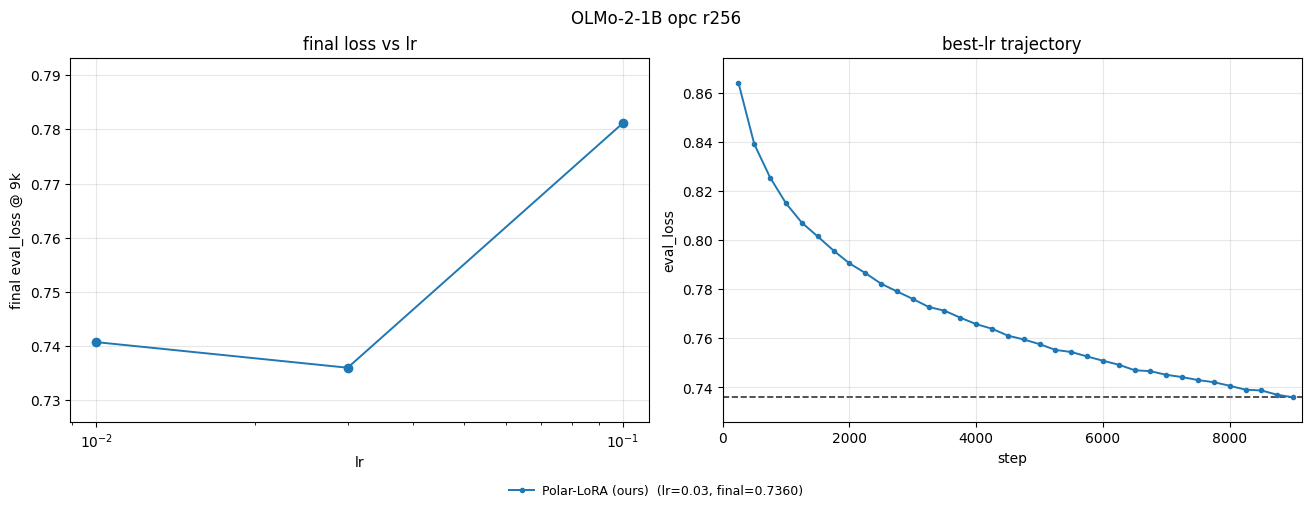

,variant,best_lr,final,delta,delta_sigma
0,Polar-LoRA (ours),0.03,0.735985,None,None


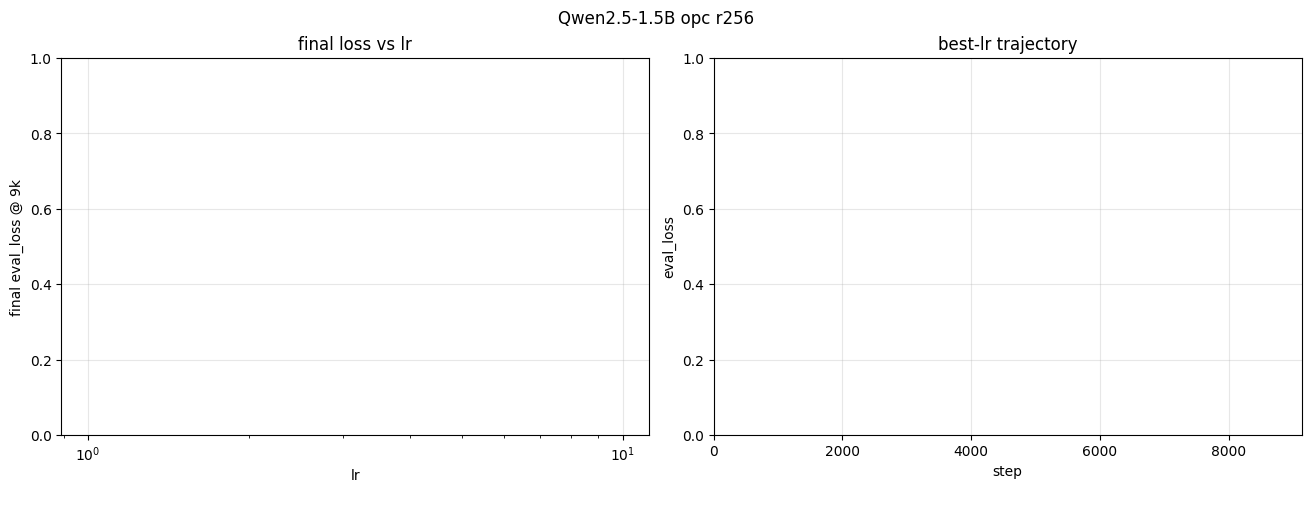

""


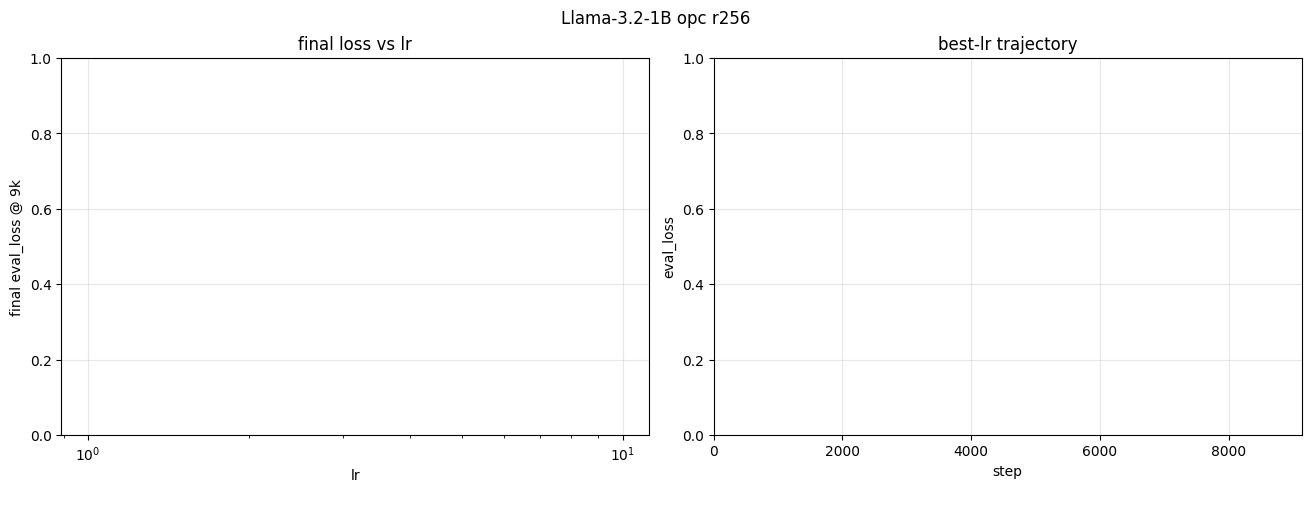

""


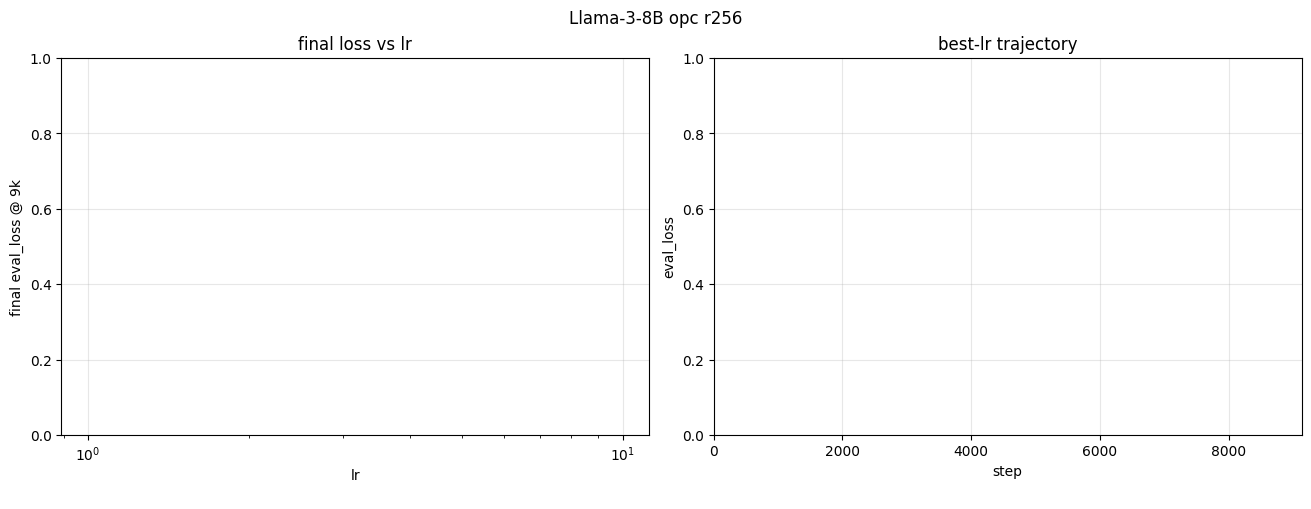

""


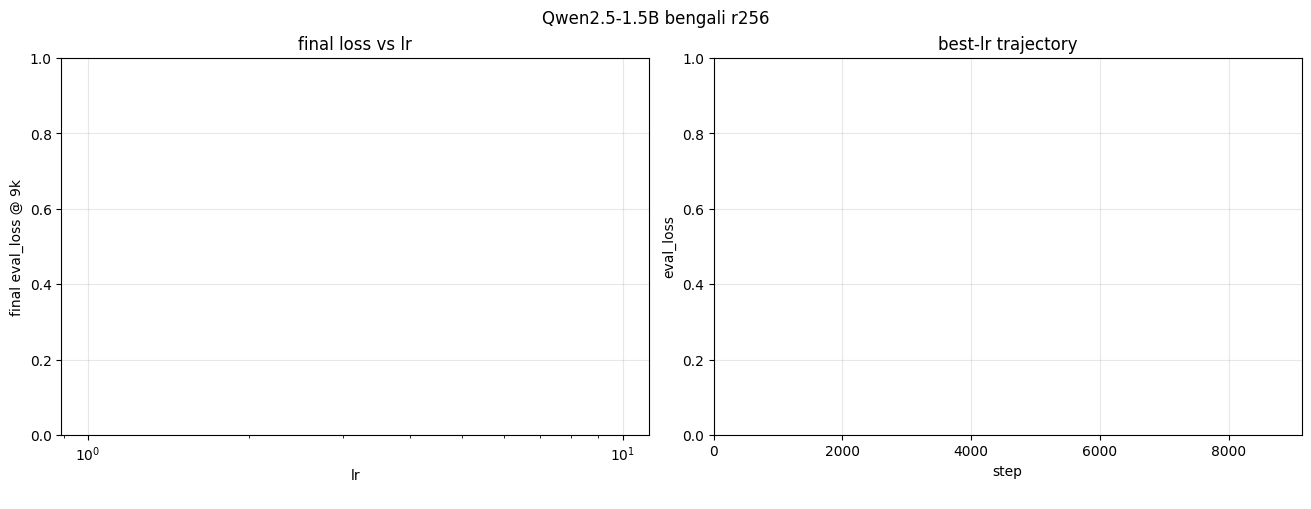

""


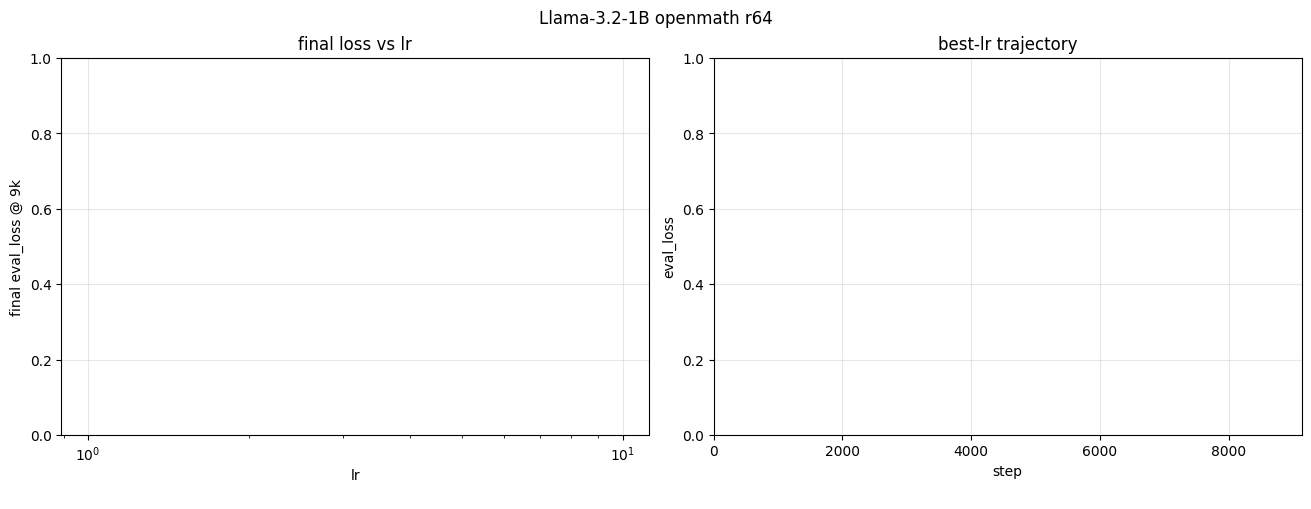

""


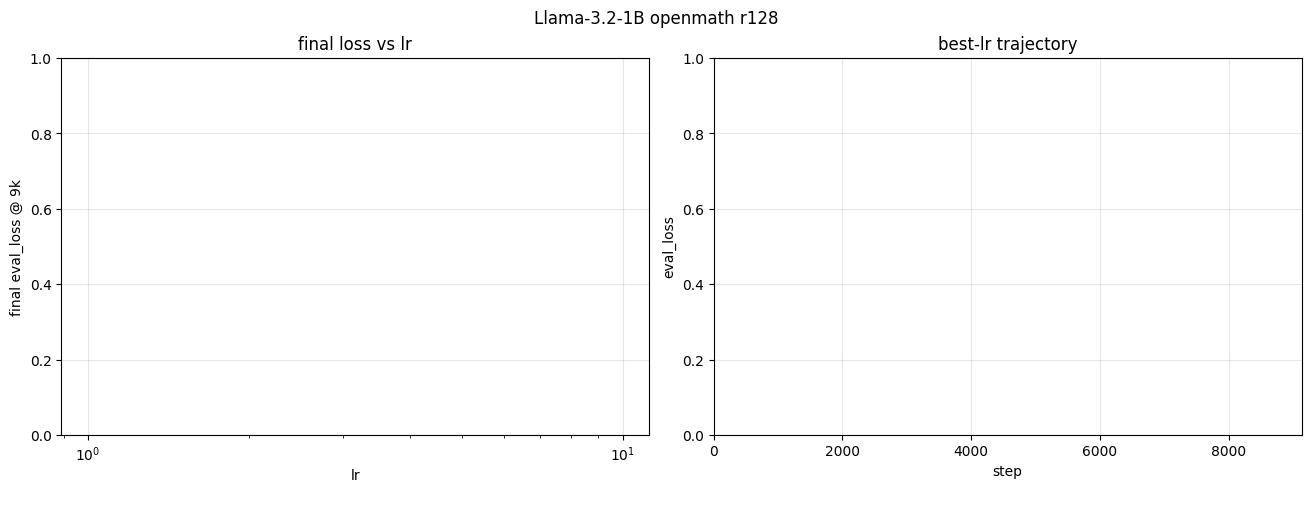

""


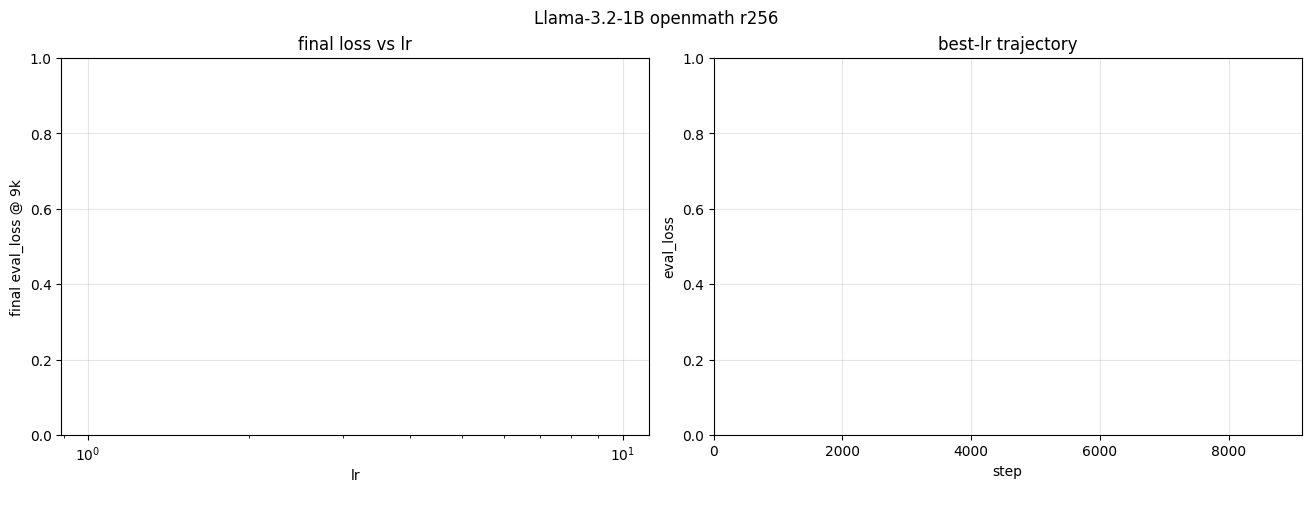

""


In [3]:
for name, model, key, rank in CELLS:
    common = dict(model_name=model, lora_r=rank, data_dir=(lambda d, k=key: k in str(d)))
    try:
        fig, _tdf, sdf = compare_variants_figure(
            {'Polar-LoRA (ours)': PROTO, 'iMuon': IMUON},
            common_where=common, ref_label='Polar-LoRA (ours)',
            logs_root=str(ROOT / 'logs'), sigma_ref=SIGMA, max_steps=9000,
            allow_partial=True, allow_custom_labels=True, target_label='AdamW',
            suptitle=name,
        )
        plt.show()
        display(sdf)
    except Exception as e:
        print(f"[{name}] no data yet — {type(e).__name__}: {e}")